# NeuroWorkflow: Balanced E-I Network (Brunel 2000)

Classic balanced network with excitatory and inhibitory `iaf_psc_alpha` populations.
Reference: Brunel N. (2000) *Dynamics of Sparsely Connected Networks of Excitatory and Inhibitory Spiking Neurons*. J Comput Neurosci.

```
PopExc ─┐
         ├─→ NW_Connectivity → NW_SimConfig → NW_Analysis
PopInh ─┘
```

**Connectivity** (4 directed projections):
- E→E : excitatory recurrent (weight `w`, sparse)
- E→I : excitatory feedforward (weight `w`, sparse)
- I→E : inhibitory feedback (weight `-g·w`, sparse)
- I→I : inhibitory recurrent (weight `-g·w`, sparse)

External drive (ν_ext) is approximated by a bias current `I_e`.
The AI (Asynchronous Irregular) regime appears when `g > 1` and inhibition
balances excitation — neurons fire at low rates with irregular spike timing.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('../../../..'))  # neuro-workflow/src

from neuroworkflow import WorkflowBuilder
from neuroworkflow.nodes.sandbox.NW_Population   import NW_Population
from neuroworkflow.nodes.sandbox.NW_Connectivity import NW_Connectivity
from neuroworkflow.nodes.sandbox.NW_SimConfig    import NW_SimConfig
from neuroworkflow.nodes.sandbox.NW_Analysis     import NW_Analysis

## 1. Instantiate nodes

In [2]:
exc = NW_Population("PopExc")
inh = NW_Population("PopInh")

conn = NW_Connectivity("Connectivity")
cfg  = NW_SimConfig("SimConfig")
ana  = NW_Analysis("Analysis")

## 2. Configure nodes

**Brunel parameters** (scaled for fast local execution):
- N_E = 80, N_I = 20  (N_E = 4·N_I)
- ε = 0.1 — sparse random connectivity
- w = 40 pA — excitatory synaptic weight
- g = 5 — inhibitory/excitatory weight ratio
- I_e ≈ 500 pA — approximates external Poisson drive ν_ext

Increasing g pushes the network from synchronous to asynchronous irregular firing.

In [3]:
import numpy as np

# --- Brunel parameters ---
w   = 40.0   # pA  excitatory synaptic weight
g   = 5.0    # inhibitory/excitatory ratio  (w_inh = -g*w)
eps = 0.1    # connection probability (10% sparse random)

# BMTK connection_rule accepts int or callable only — lambda implements probability
sparse_random = lambda src, tgt: 1 if np.random.rand() < eps else 0

neuron_defaults = dict(
    model_type     = "point_neuron",
    model_template = "nest:iaf_psc_alpha",
    location       = "VISp",
    layer          = "L4",
    nest_params = {
        "C_m":     250.0,   # pF
        "tau_m":   10.0,    # ms
        "t_ref":   2.0,     # ms
        "V_th":    -55.0,   # mV
        "V_reset": -70.0,   # mV
        "E_L":     -70.0,   # mV
        "I_e":     500.0,   # pA  — approximates ν_ext external Poisson drive
    },
)

exc.configure(pop_name="exc", N=80,  ei_type="exc", **neuron_defaults)
inh.configure(pop_name="inh", N=20,  ei_type="inh", **neuron_defaults)

conn.configure(
    connection_rule      = sparse_random,
    model_template       = "static_synapse",
    dynamics_params      = "syn.json",
    dynamics_params_dict = {},
    delay                = 1.5,           # ms  (Brunel standard)
    syn_weight           = w,
    allow_autapses       = False,
    allow_multapses      = False,

    connections = [
        # E→E : excitatory recurrent
        {"source": "exc", "target": "exc", "syn_weight":  w},
        # E→I : excitatory feedforward
        {"source": "exc", "target": "inh", "syn_weight":  w},
        # I→E : inhibitory feedback  (negative = inhibitory for iaf_psc_alpha)
        {"source": "inh", "target": "exc", "syn_weight": -g * w},
        # I→I : inhibitory recurrent
        {"source": "inh", "target": "inh", "syn_weight": -g * w},
    ],
)

cfg.configure(
    simulator   = "pointnet",
    config_file = "config_balanced.json",
    tstop_ms    = 1000.0,
    dt_ms       = 0.1,
    reports = {
        "v_report": {
            "variable_name": "V_m",
            "cells":         "all",
            "module":        "membrane_report",
            "sections":      "soma",
        }
    },
)

ana.configure(
    plot_raster  = True,
    plot_traces  = True,
    report_name  = "v_report",
    save_figures = True,
)

## 3. Build and run the workflow

Both populations connect to the **same** Connectivity fan-in port.
NW_Connectivity builds the 4-projection E-I connectivity matrix.

Executing node: PopInh
Executing node: PopExc
Executing node: Connectivity
Executing node: SimConfig

              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Mar  4 2025 17:27:39

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

2026-06-17 14:21:04,560 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-06-17 14:21:04,582 [INFO] Batch processing nodes for exc/0.


INFO:NestIOUtils:Batch processing nodes for exc/0.


2026-06-17 14:21:04,594 [INFO] Batch processing nodes for inh/0.


...

2026-06-17 14:21:05,057 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-06-17 14:21:05,208 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: Analysis


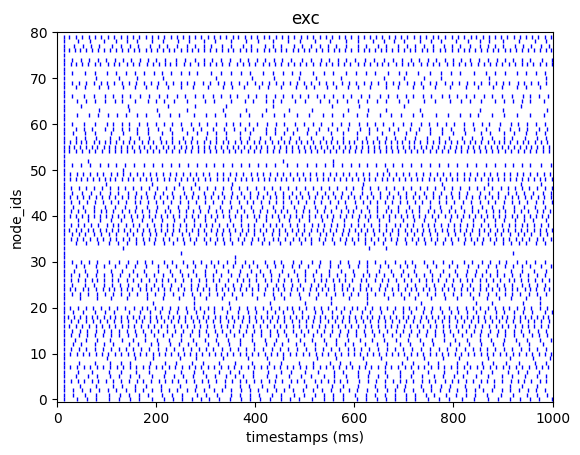

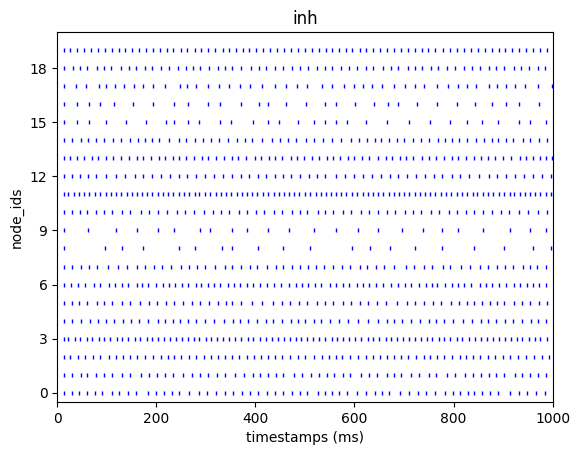

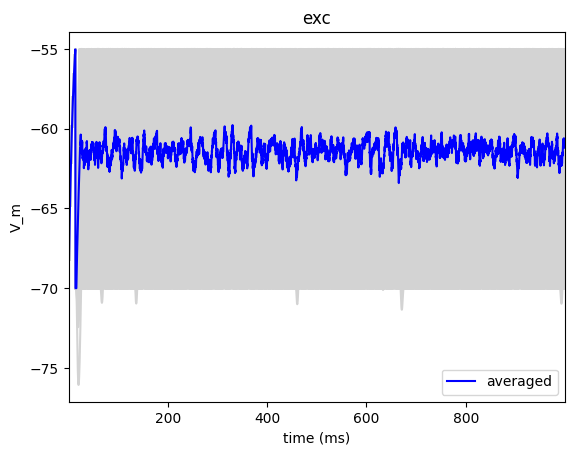

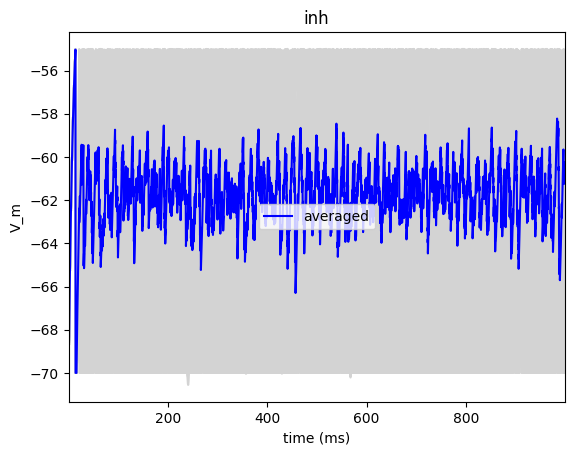

Workflow completed successfully


In [4]:
wf = WorkflowBuilder("NW_BalancedNetwork")

for node in [exc, inh, conn, cfg, ana]:
    wf.add_node(node)

# Fan-in: both populations → single Connectivity port
wf.connect("PopExc", "population", "Connectivity", "populations")
wf.connect("PopInh", "population", "Connectivity", "populations")

wf.connect("Connectivity", "network", "SimConfig", "populations")
wf.connect("SimConfig",    "results", "Analysis",  "results")

wf.context["results_path"] = "./results/balanced"

workflow = wf.build()
ok = workflow.execute()
assert ok, "Workflow failed — check printed errors above"
print("Workflow completed successfully")

## 4. Validate outputs

In [5]:
print("Output validation:")
for node_name, node in workflow.nodes.items():
    for port_name, port in node._output_ports.items():
        status = "OK" if port.value is not None else "*** None — node may have failed ***"
        print(f"  {node_name}.{port_name}: {status}")

Output validation:
  PopExc.population: OK
  PopInh.population: OK
  Connectivity.network: OK
  SimConfig.results: OK
  Analysis.figures: OK


## 5. Re-run: increase g to push into AI regime

Higher `g` → stronger inhibition → sparser, more irregular firing.
Brunel's AI regime typically appears around `g = 4–6`.
No need to rebuild — just reconfigure and re-execute.

Executing node: PopInh
Executing node: PopExc
Executing node: Connectivity
Executing node: SimConfig
2026-06-17 14:21:11,997 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-06-17 14:21:12,009 [INFO] Batch processing nodes for exc/0.


INFO:NestIOUtils:Batch processing nodes for exc/0.


2026-06-17 14:21:12,020 [INFO] Batch processing nodes for inh/0.


...

2026-06-17 14:21:12,492 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-06-17 14:21:12,645 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: Analysis


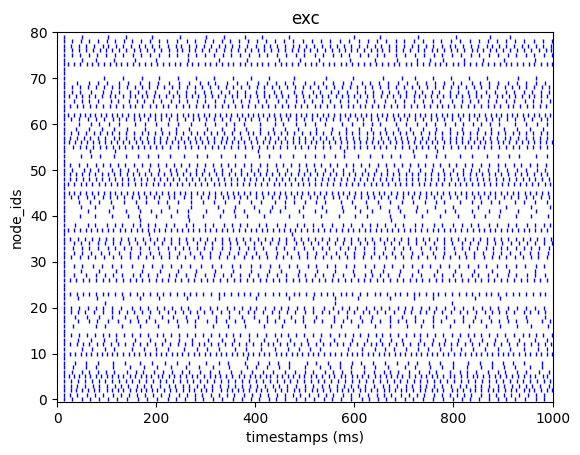

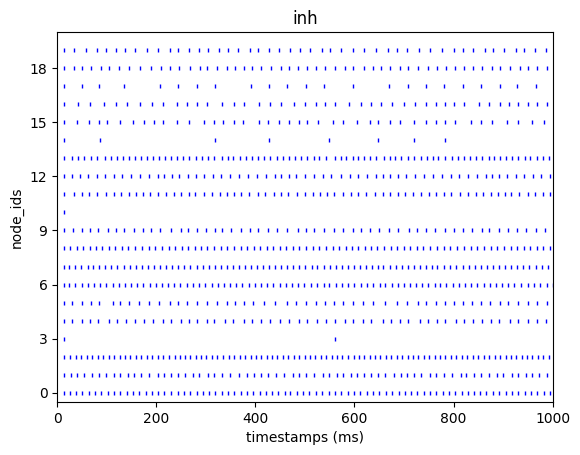

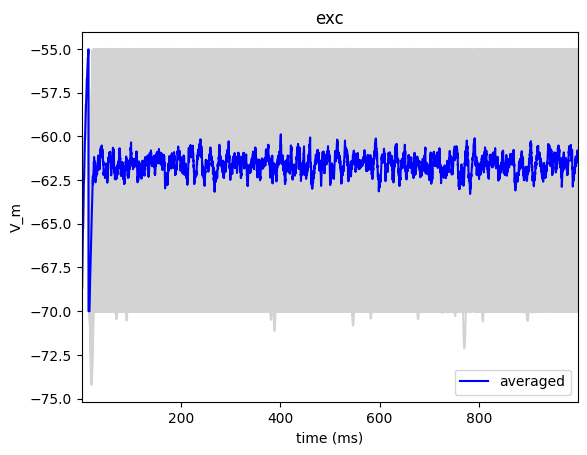

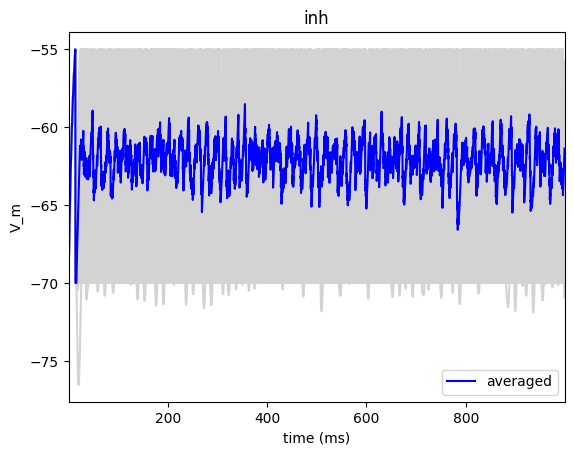

Re-run complete (g=6.0)


In [6]:
g_strong = 6.0

conn.configure(
    connections = [
        {"source": "exc", "target": "exc", "syn_weight":  w},
        {"source": "exc", "target": "inh", "syn_weight":  w},
        {"source": "inh", "target": "exc", "syn_weight": -g_strong * w},
        {"source": "inh", "target": "inh", "syn_weight": -g_strong * w},
    ],
)
cfg.configure(config_file="config_balanced_g6.json")

for node in workflow.nodes.values():
    node._context["results_path"] = "./results/balanced_g6"

ok = workflow.execute()
assert ok, "Re-run failed"
print(f"Re-run complete (g={g_strong})")